```{=html}
<style>
.value-box-value { font-size: 1.6rem !important; }
.value-box-title { font-size: 0.9rem !important; }
</style>
```

In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from gapminder import gapminder
from IPython.display import HTML, display
import plotly.express as px
import plotly.io as pio

# Emit only the plotly mimetype — Quarto will render it with its own
# Plotly.js bundle and avoid the RequireJS "Mismatched anonymous define" clash
pio.renderers.default = "iframe"

df = gapminder.copy()
df_latest = df[df["year"] == df["year"].max()]

# Consistent colors for continents across all plots
continent_palette = {
    "Africa":   "#e41a1c",
    "Americas": "#377eb8",
    "Asia":     "#4daf4a",
    "Europe":   "#984ea3",
    "Oceania":  "#ff7f00",
}
continent_order = list(continent_palette.keys())

In [2]:
#| content: valuebox
#| title: "Countries"
#| icon: globe
#| color: primary
dict(value = df["country"].nunique())

{'value': 142}

In [3]:
#| content: valuebox
#| title: "Years Covered"
#| icon: calendar
dict(value = f'{df["year"].min()}–{df["year"].max()}')

{'value': '1952–2007'}

In [4]:
#| content: valuebox
#| title: "Continents"
#| icon: map
dict(value = df["continent"].nunique())

{'value': 5}

<Axes: xlabel='gdpPercap', ylabel='lifeExp'>

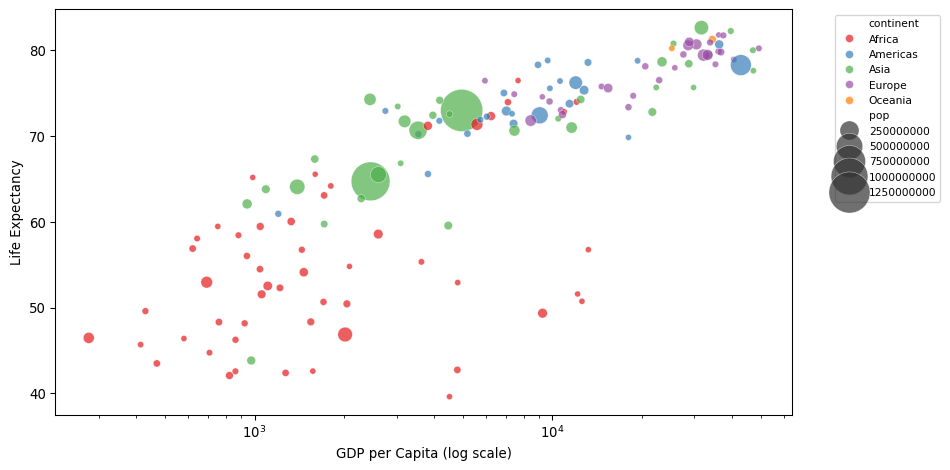

In [5]:
#| title: GDP and Life Expectancy (2007)
fig, ax = plt.subplots(figsize=(10, 5))
sns.scatterplot(
    data=df_latest, x="gdpPercap", y="lifeExp",
    hue="continent", hue_order=continent_order, palette=continent_palette,
    size="pop", sizes=(20, 1000), alpha=0.7, ax=ax
)
ax.set_xscale("log")
_ = ax.set_xlabel("GDP per Capita (log scale)")
_ = ax.set_ylabel("Life Expectancy")
_ = ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()



Each **bubble** is a country in 2007. The **bubble size** corresponds to the population

Richer countries clearly cluster in the top-right. Antother key observation is that gains in life expectancy flatten once GDP rises above ~$10k.


In [6]:
#| title: Animated GDP vs Life Expectancy
fig = px.scatter(
    df, x="gdpPercap", y="lifeExp",
    animation_frame="year", animation_group="country",
    size="pop", color="continent",
    color_discrete_map=continent_palette,
    category_orders={"continent": continent_order},
    hover_name="country",
    facet_col="continent", log_x=True, size_max=45,
    range_x=[100, 100000], range_y=[25, 90],
)
fig

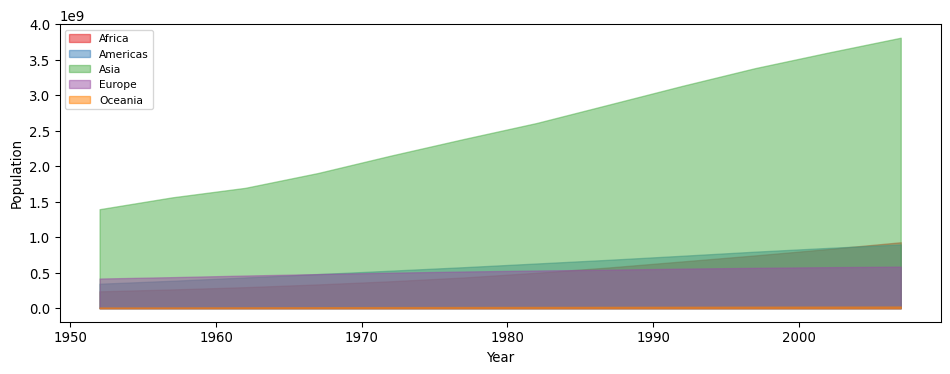

In [7]:
#| title: Population
pop_by_year = df.groupby(["year", "continent"])["pop"].sum().reset_index()
fig, ax = plt.subplots(figsize=(10, 4))
for continent in continent_order:
    data = pop_by_year[pop_by_year["continent"] == continent]
    _ = ax.fill_between(
        data["year"], data["pop"],
        color=continent_palette[continent], alpha=0.5, label=continent,
    )
_ = ax.set_xlabel("Year")
_ = ax.set_ylabel("Population")
_ = ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

<Axes: xlabel='year', ylabel='lifeExp'>

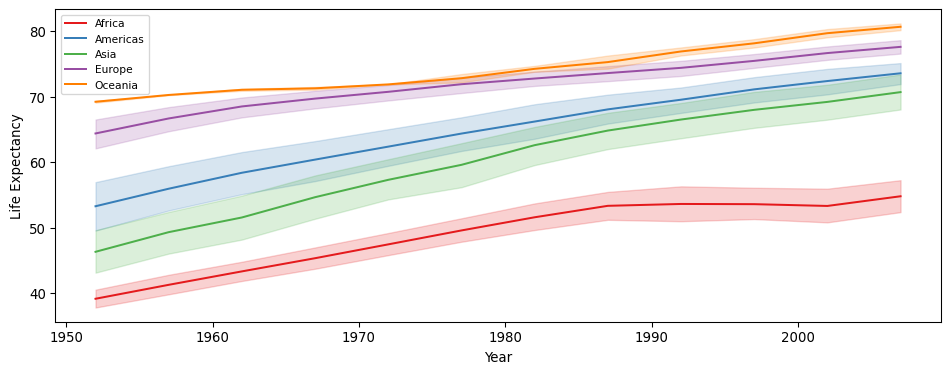

In [8]:
#| title: Life Expectancy
fig, ax = plt.subplots(figsize=(10, 4))
sns.lineplot(
    data=df, x="year", y="lifeExp",
    hue="continent", hue_order=continent_order, palette=continent_palette,
    estimator="mean", errorbar=("ci", 95), ax=ax,
)
_ = ax.set_xlabel("Year")
_ = ax.set_ylabel("Life Expectancy")
_ = ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

<Axes: xlabel='continent', ylabel='gdpPercap'>

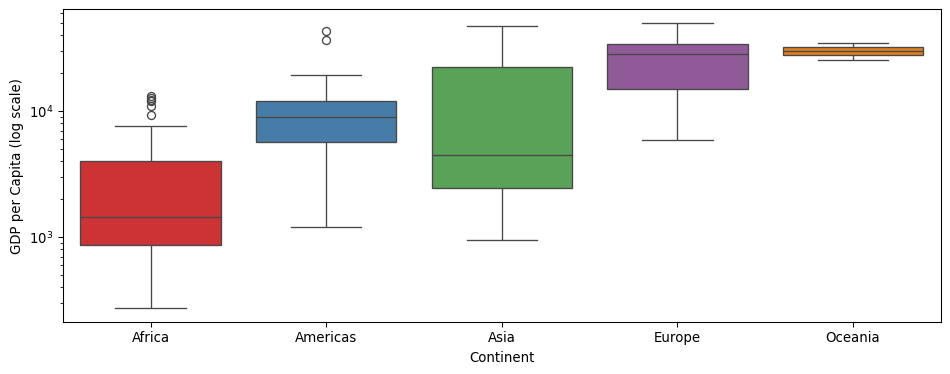

In [9]:
#| title: GDP Distribution
fig, ax = plt.subplots(figsize=(10, 4))
sns.boxplot(
    data=df_latest, x="continent", y="gdpPercap",
    hue="continent", hue_order=continent_order, palette=continent_palette,
    order=continent_order, ax=ax,
)
_ = ax.set_yscale("log")
_ = ax.set_xlabel("Continent")
_ = ax.set_ylabel("GDP per Capita (log scale)")
plt.tight_layout()
plt.show()

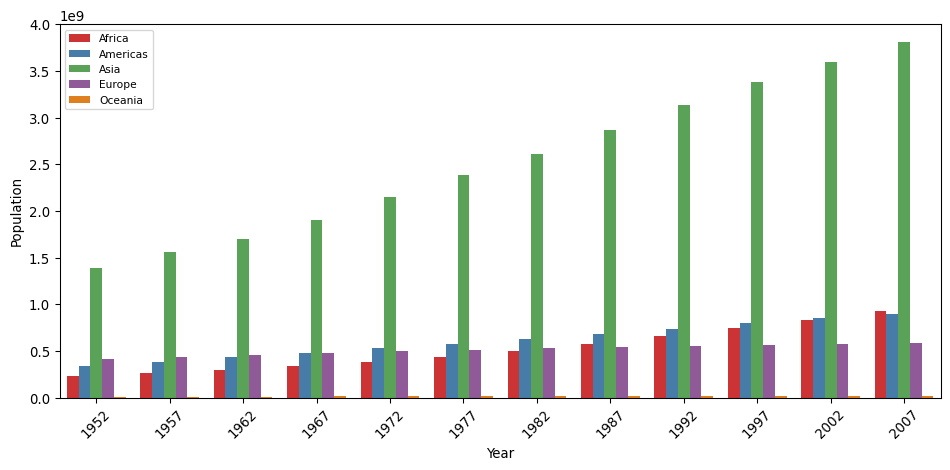

In [10]:
#| title: Population by Continent
pop_by_cont = df.groupby(["year", "continent"])["pop"].sum().reset_index()
fig, ax = plt.subplots(figsize=(10, 5))
_ = sns.barplot(
    data=pop_by_cont, x="year", y="pop",
    hue="continent", hue_order=continent_order, palette=continent_palette,
    ax=ax,
)
_ = ax.set_xlabel("Year")
_ = ax.set_ylabel("Population")
_ = ax.legend(fontsize=8)
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

<Axes: xlabel='continent', ylabel='lifeExp'>

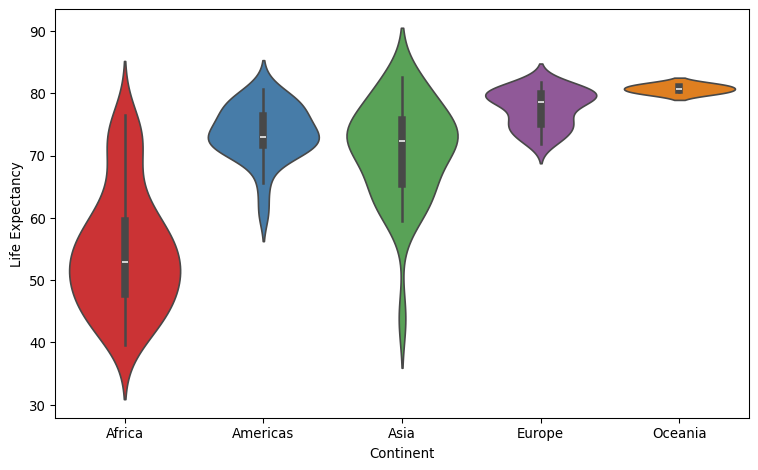

In [11]:
#| title: Life Expectancy Distribution
fig, ax = plt.subplots(figsize=(8, 5))
sns.violinplot(
    data=df_latest, x="continent", y="lifeExp",
    hue="continent", hue_order=continent_order, palette=continent_palette,
    order=continent_order, ax=ax,
)
_ = ax.set_xlabel("Continent")
_ = ax.set_ylabel("Life Expectancy")
plt.tight_layout()
plt.show()


Learn more about the Gapminder dataset at <https://www.gapminder.org/data/documentation/>


In [12]:

from itables import show
show(df, showIndex = False)


/home/duerr/micromamba/envs/teaching/lib/python3.11/site-packages/itables/typing.py:302: SyntaxWarning:

These arguments are not documented in ITableOptions: {'info', 'responsive', 'searching', 'dom', 'lengthChange'}. You can silence this warning by setting `itables.options.warn_on_undocumented_option=False`. If you believe ITableOptions should be updated, please make a PR or open an issue at https://github.com/mwouts/itables

/home/duerr/micromamba/envs/teaching/lib/python3.11/site-packages/itables/typing.py:302: SyntaxWarning:

These arguments are not documented in DTForITablesOptions: {'info', 'responsive', 'searching', 'dom', 'lengthChange'}. You can silence this warning by setting `itables.options.warn_on_undocumented_option=False`. If you believe ITableOptions should be updated, please make a PR or open an issue at https://github.com/mwouts/itables



Loading ITables v2.7.3 from the internet... (need help?)
